# Stability Breeds Instability 🌋
### Does a long, quiet market plant the seeds of the next crash?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Beat 0 · Verdict (real tape).** Long stretches of unusually low volatility *were* followed by
somewhat deeper drawdowns over the next two years — the opposite of what a quiet market
"should" do — but not by enough to rule out luck (a no-feedback volatility model produces a
slope at least this large 0.08–0.06 of the time, depending on the model). And
selling the calm did not pay: a rule that halved its stocks during long calms finished with a
slightly *lower* risk-adjusted return than simply holding.

> 📓 **This is the plain-language layer.** The regressions, both simulated null worlds, the
> robustness grid and the costs are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
> Headline numbers come from the pinned run in [`docs/results.md`](../docs/results.md)
> (as-of 2018-11-30, fingerprint `394be76d78ac`); every chart below is recomputed from the
> frozen tapes by the code beside it.
>
> ⚠️ **Not investment advice.**

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore")
from calm import data, strategy as st
ff = data.load_ff()
r, rf = ff["mkt"], ff["rf"]
sig = st.calm_signal(r)
print(f"Fama-French monthly TOTAL return, {ff.index[0].date()} -> {ff.index[-1].date()} "
      f"(as-of {data.AS_OF}), fingerprint {data.fingerprint(ff)}")

Fama-French monthly TOTAL return, 1926-07-31 -> 2018-11-30 (as-of 2018-11-30), fingerprint 394be76d78ac


## 1 · The claim

The economist **Hyman Minsky** had a famous one-liner: *stability is destabilising.* When markets
are calm for years, everyone's risk models say risk is low, so everyone takes more of it —
more leverage, more selling of insurance, more reaching for yield. The calm itself builds the
fragility that ends it.

In 2018 Jón Danielsson, Marcela Valenzuela and Ilknur Zer took this to the data (*"Learning
from History: Volatility and Financial Crises"*, Review of Financial Studies). Across many
countries and two centuries, long periods of **unusually low** stock-market volatility —
measured against its own slow-moving trend — came before banking crises. On trading desks the
same idea travels as a slogan: **"low VIX = complacency = sell."**

## 2 · So what?

If it's true, two things follow. First, the calm periods everyone enjoys are the *dangerous*
ones, and a regulator or a risk manager should get *more* nervous when the dashboards go quiet.
Second, there's money in it: step out of the market when calm has gone on too long and you
dodge the crash that follows.

There's a catch that makes this much harder to test than it sounds, and it's the heart of the
study.

## 3 · How we'd know — and the catch

**The catch: volatility comes back.** Markets have moods. A quiet month is usually followed by
another quiet month (volatility *clusters*), but no mood lasts forever — volatility drifts
back towards its average (it *mean-reverts*). So *any* very calm stretch will, eventually, be
followed by something less calm. That happens even in a world where nobody ever changes their
behaviour.

So "calm was followed by storm" isn't enough. We need: **was it followed by *more* storm than
mean reversion alone would produce?**

The plan, fixed before looking:

1. **A "prolonged calm" score**, using only the past: how far below its own 10-year average
   volatility has been, averaged over the last 5 years.
2. **What came next**: the worst peak-to-trough fall over the next 2 years (and 1, 3, 12, 36
   months, for context).
3. **Two fake worlds** fitted to the real market — they reproduce its clustering and its
   mean reversion but contain **no** Minsky feedback. We run the identical test on hundreds of
   them. The real market has to beat them.
4. **A trade**: halve the stocks after a long calm, against simply holding.

*Mirage* would mean: the real link is no stronger than the fake worlds produce, or the trade
doesn't beat holding.

## 4 · The teardown

### 4.1 Ninety years of calm and storm

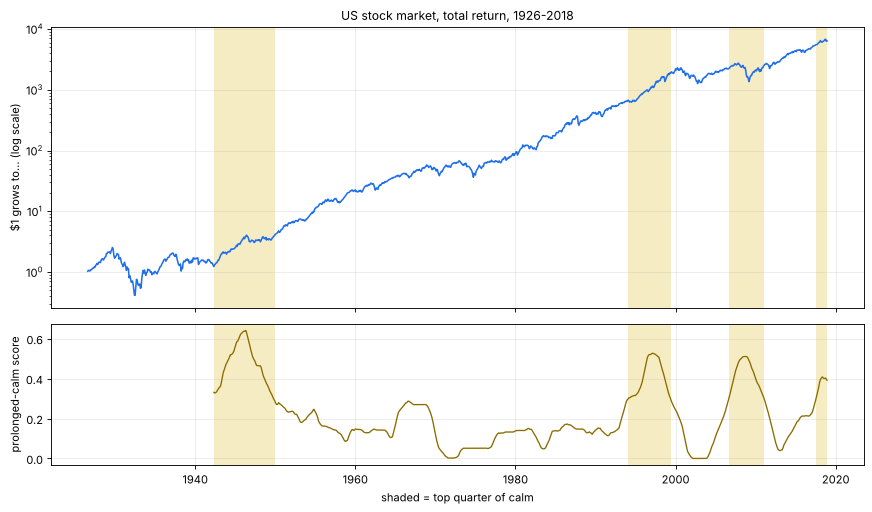

In [2]:
wealth = (1 + r).cumprod()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.semilogy(wealth.index, wealth, color="#1f6feb", lw=1.4)
a1.set_ylabel("$1 grows to... (log scale)")
a1.set_title("US stock market, total return, 1926-2018", fontsize=11)
c = sig["calm"]
hi = c > c.quantile(0.75)
for ax in (a1, a2):
    ax.fill_between(c.index, 0, 1, where=hi.to_numpy(), transform=ax.get_xaxis_transform(),
                    color="#dab617", alpha=0.25, lw=0)
a2.plot(c.index, c, color="#8a6d00", lw=1.2)
a2.set_ylabel("prolonged-calm score")
a2.set_xlabel("shaded = top quarter of calm")
plt.tight_layout(); plt.show()

The shaded stretches are the calmest quarter of the record: the 1940s (calm compared with
the Depression-era norm), 1994-99, 2006-2011 and 2017-18. The score is slow on purpose — it is
a five-year average — so it stays high right through the 2008 crash it "preceded". Three of the
four calm runs were followed by a fall of 20% or more (1946-47, 2000-02, 2008); the last one
runs out of data in November 2018, a month before the Christmas sell-off. That looks
impressive, and it is also only four episodes.

### 4.2 Were calm periods followed by more crashes?

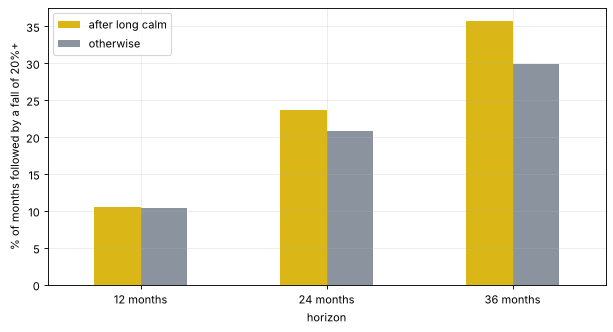

           after long calm  otherwise
horizon                              
12 months          10.6000    10.4000
24 months          23.7000    20.8000
36 months          35.7000    29.9000

separate 20%+ crashes in the whole sample: 7


In [3]:
rows = []
for H in (12, 24, 36):
    o = st.crash_odds(r, rf, H)
    rows.append({"horizon": f"{H} months", "after long calm": o["p_calm"],
                 "otherwise": o["p_rest"]})
t = pd.DataFrame(rows).set_index("horizon")
ax = (t * 100).plot.bar(color=["#dab617", "#8b949e"], figsize=(9, 4.5), rot=0)
ax.set_ylabel("% of months followed by a fall of 20%+")
plt.show()
print((t * 100).round(1).to_string())
print(f"\nseparate 20%+ crashes in the whole sample: {st.crash_odds(r, rf, 24)['n_episodes']}")

A little more often — 23.7% vs 20.8% at two years — but these months overlap
heavily, and the whole comparison rests on only **7 separate crashes** since the score
begins in 1942. That is very little to go on.

### 4.3 The real test: beat a world with no Minsky in it

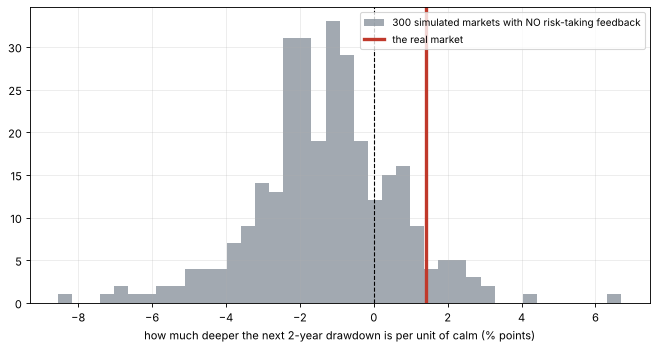

real: +1.41%   fake worlds, on average: -1.30%
share of fake worlds at least as extreme as the real one: 0.07


In [4]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m = st.mean_reversion_null(ff, "garch", 24, n_paths=300, seed=1021)
null = m["_null_samples"]["mdd"]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.hist(null * 100, bins=40, color="#8b949e", alpha=0.8,
        label="300 simulated markets with NO risk-taking feedback")
ax.axvline(m["mdd"]["real"] * 100, color="#c0392b", lw=3, label="the real market")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("how much deeper the next 2-year drawdown is per unit of calm (% points)")
ax.legend(fontsize=9); plt.show()
print(f"real: {m['mdd']['real']:+.2%}   fake worlds, on average: {m['mdd']['null_mean']:+.2%}")
print(f"share of fake worlds at least as extreme as the real one: {m['mdd']['p_value']:.2f}")

This is the picture to remember. In the fake worlds — which copy the real market's mood swings
but contain no Minsky — calm is followed by *smaller* drawdowns on average (−1.3% per
unit of calm): quiet markets tend to stay quiet for a while. The real market went the other
way (+1.4%). That's interesting! But roughly one fake world in thirteen to one in
eighteen does it too, by pure chance. The usual bar is one in twenty, and we don't clear it.

> 🔬 **For the quants.** One-sided p = 0.08 against GARCH(1,1)-t and 0.06 against
> a long-memory FIGARCH-t, each fitted to the same 92 years. The raw Newey-West t is only
> 0.88. Details and a nine-way robustness grid in notebook 02.

### 4.4 Two horizons, two answers

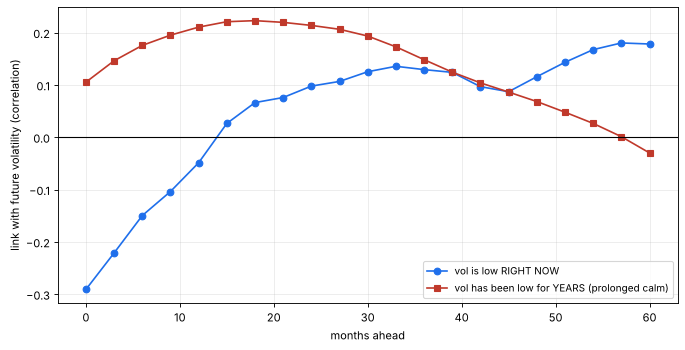

In [5]:
prof_now = st.vol_horizon_profile(r, -sig["dev"])
prof_calm = st.vol_horizon_profile(r, sig["calm"])
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(prof_now["h"], prof_now["corr"], "o-", color="#1f6feb",
        label="vol is low RIGHT NOW")
ax.plot(prof_calm["h"], prof_calm["corr"], "s-", color="#c0392b",
        label="vol has been low for YEARS (prolonged calm)")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("months ahead"); ax.set_ylabel("link with future volatility (correlation)")
ax.legend(fontsize=9); plt.show()

The blue line is the part everybody agrees on: if the market is quiet *now*, it's very likely
to be quiet over the next few months. Calm predicts calm. The red line is the Minsky claim:
after *years* of calm, volatility a year or three out tends to be a bit higher. Both are
visible; only the first is beyond doubt.

## 5 · The verdict

**Signal: Weak.** The real market leans Minsky's way — long calm, then somewhat deeper
falls, when a no-feedback world would predict shallower ones — but the lean sits at
p ≈ 0.08/0.06 against two fake worlds, the raw statistic is far from significant
(t = 0.88), it depends on how you define "calm" (it clears p < 0.10 for 4 of 9
reasonable definitions), and it lives entirely in the second half of the sample
(−0.9% before 1979, +3.9% after). Literature support plus a suggestive tape reads Weak.

**Tradability: Mirage.** See below.

## 6 · Could you trade it?

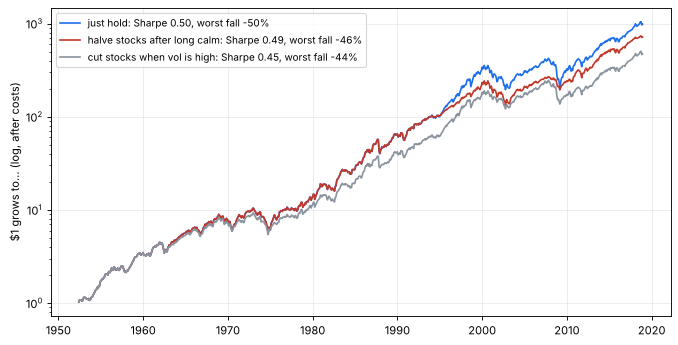

In [6]:
W = {k: st.rule_weights(r, k) for k in ("buy_hold", "calm_derisk", "vol_target")}
start = max(W["calm_derisk"].first_valid_index(), W["vol_target"].first_valid_index())
names = {"buy_hold": "just hold", "calm_derisk": "halve stocks after long calm",
         "vol_target": "cut stocks when vol is high"}
cols = {"buy_hold": "#1f6feb", "calm_derisk": "#c0392b", "vol_target": "#8b949e"}
fig, ax = plt.subplots(figsize=(10, 5))
for k, w in W.items():
    bt = st.backtest(ff.loc[start:], w.loc[start:], 10.0)
    s = st.summary(bt)
    ax.semilogy((1 + bt["net"]).cumprod(), color=cols[k], lw=1.5,
                label=f"{names[k]}: Sharpe {s['sharpe_net']:.2f}, worst fall {s['max_dd']:.0%}")
ax.set_ylabel("$1 grows to... (log, after costs)"); ax.legend(fontsize=9); plt.show()

Halving your stocks whenever calm has gone on unusually long (decided at month-end, acted on
the next month, after trading costs, with the cash earning T-bill interest) trimmed the worst
fall from −50% to −46% — and cost you money: $1 became 717× instead of
986× over 67 years, and the risk-adjusted return slipped from 0.496 to
0.487. Costs aren't the problem — it barely trades. The problem is that long calms
are usually **good** times to own stocks, and the rule sits half out of them for years. The
crashes it partly dodges don't pay for the rallies it misses. **Mirage.**

## 7 · Going further

- **The VIX anecdote.** The VIX averaged 11.1 through 2017 — the calmest year it had ever
  recorded — then spiked to 37.3 in February 2018, and the S&P 500 fell −19.8% by
  Christmas. It's the story everyone tells, and it's **one** episode on a five-year tape. One
  story can't prove a pattern; notebook 02 shows it, labelled as exactly that.
- **Crises are not crashes.** Danielsson and co-authors predict *banking crises* across 60
  countries. We tested the trader's version on US stocks. A fork with a cross-country crisis
  dataset would test the original claim.
- **The best lead we left open.** Long calm lines up with *higher volatility* one to three years
  out more clearly than with crashes. It wasn't our pre-registered test, so it doesn't move the
  verdict — but it's the first thing to pre-register next.
- **What to challenge:** the calm definition (10-year trend, 5-year window), the 2-year horizon,
  the fake-world models. Each is one argument in [`calm/strategy.py`](../calm/strategy.py).